In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('mushroom_Dataset.csv')

In [3]:
df.head()

,cap-diameter,cap-shape,gill-attachment,gill-color,stem-height,stem-width,stem-color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


In [4]:

df_info = df.info()  # Display the dataframe info
missing_values = df.isnull().sum()  # Check for missing values
duplicates = df.duplicated().sum()  # Check for duplicate rows
df_types = df.dtypes  # Get the data types of each column

# You can print or return these values to inspect them
df_info, missing_values, duplicates, df_types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54035 entries, 0 to 54034
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cap-diameter     54035 non-null  int64  
 1   cap-shape        54035 non-null  int64  
 2   gill-attachment  54035 non-null  int64  
 3   gill-color       54035 non-null  int64  
 4   stem-height      54035 non-null  float64
 5   stem-width       54035 non-null  int64  
 6   stem-color       54035 non-null  int64  
 7   season           54035 non-null  float64
 8   class            54035 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.7 MB


(None,
 cap-diameter       0
 cap-shape          0
 gill-attachment    0
 gill-color         0
 stem-height        0
 stem-width         0
 stem-color         0
 season             0
 class              0
 dtype: int64,
 303,
 cap-diameter         int64
 cap-shape            int64
 gill-attachment      int64
 gill-color           int64
 stem-height        float64
 stem-width           int64
 stem-color           int64
 season             float64
 class                int64
 dtype: object)

In [ ]:
df = df.drop_duplicates()

# Check if duplicates are removed
duplicate_check = df.duplicated().sum()
duplicate_check

0

In [5]:
# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate IQR for outlier detection
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Define the outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = ((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound))

# Count outliers for each column
outlier_count = outliers.sum()

outlier_count


,0
cap-diameter,960
cap-shape,0
gill-attachment,0
gill-color,0
stem-height,1825
stem-width,702
stem-color,0
season,6438
class,0


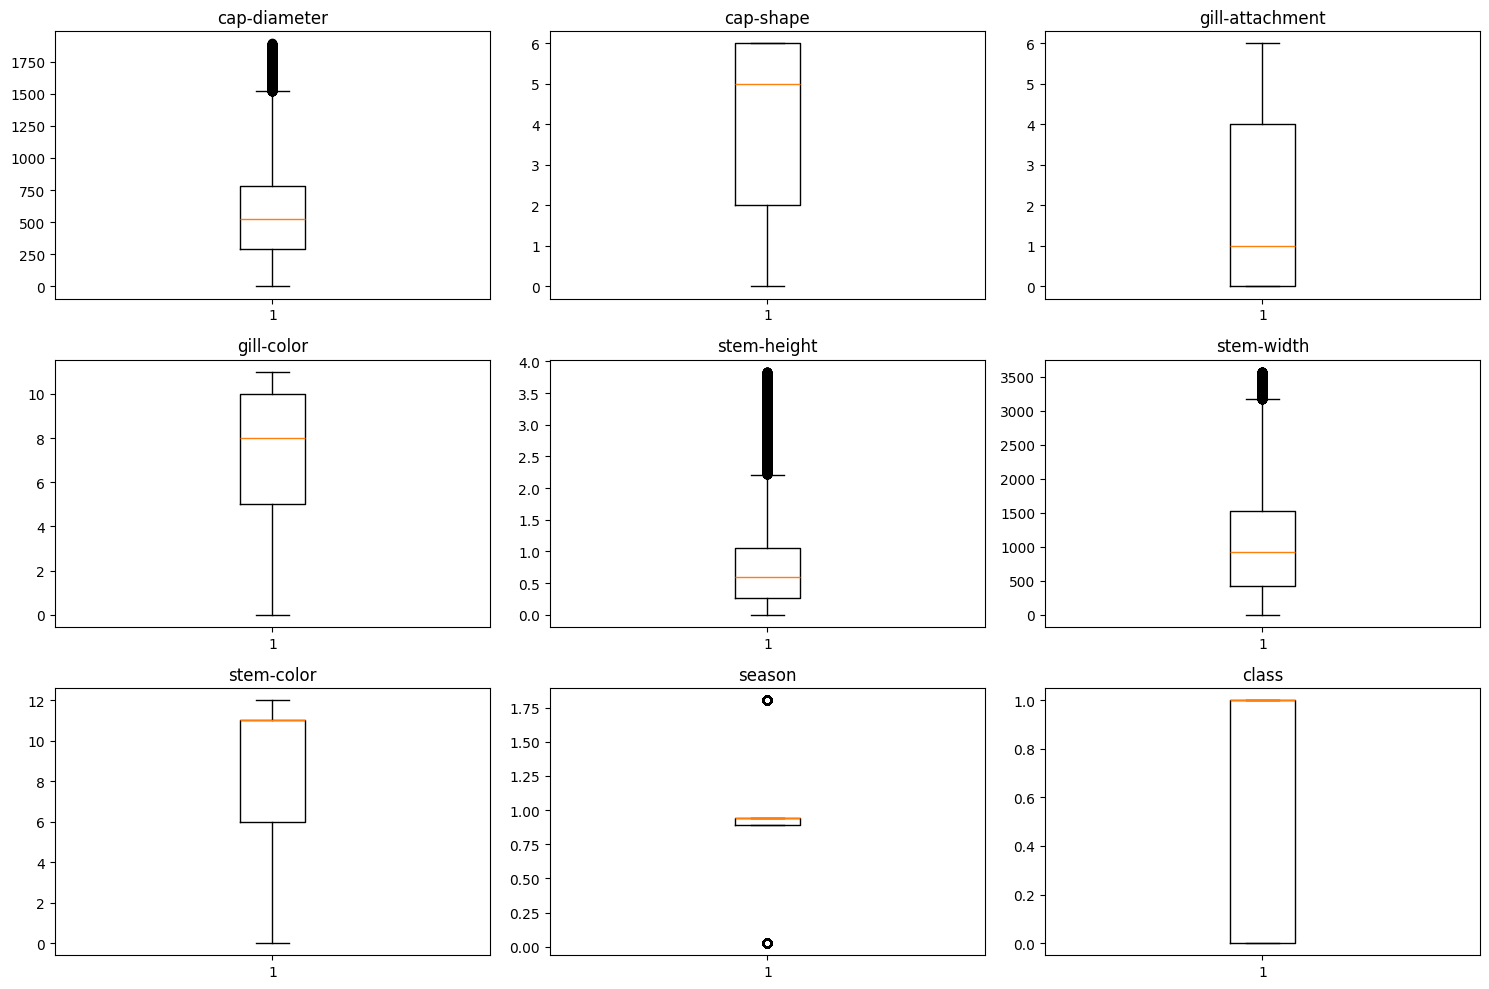

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)  # 3 rows and 3 columns layout
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [6]:
# Remove rows with outliers based on the IQR method
df = df[~((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).any(axis=1)]

# Check the new shape after removing outliers
df_info_after_outliers_removal = df.info()

df_info_after_outliers_removal


<class 'pandas.core.frame.DataFrame'>
Index: 44867 entries, 11 to 54034
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cap-diameter     44867 non-null  int64  
 1   cap-shape        44867 non-null  int64  
 2   gill-attachment  44867 non-null  int64  
 3   gill-color       44867 non-null  int64  
 4   stem-height      44867 non-null  float64
 5   stem-width       44867 non-null  int64  
 6   stem-color       44867 non-null  int64  
 7   season           44867 non-null  float64
 8   class            44867 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 3.4 MB


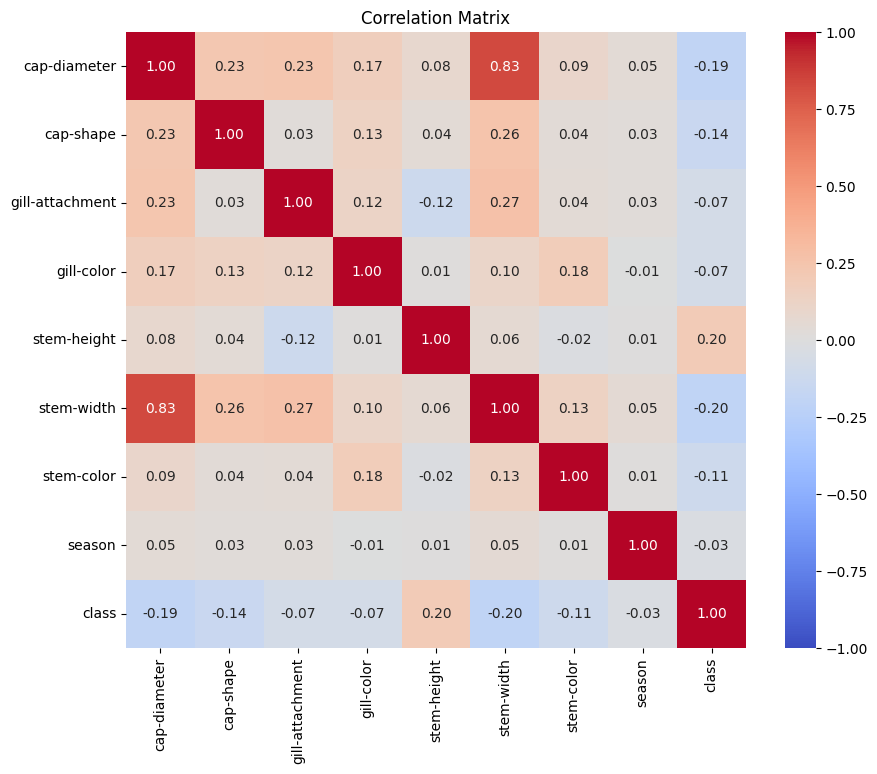

In [ ]:
import seaborn as sns
# Select numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Check the distribution of the target variable 'class' to see if the dataset is balanced
class_distribution = df['class'].value_counts()

class_distribution


,count
class,
1,25465
0,19179


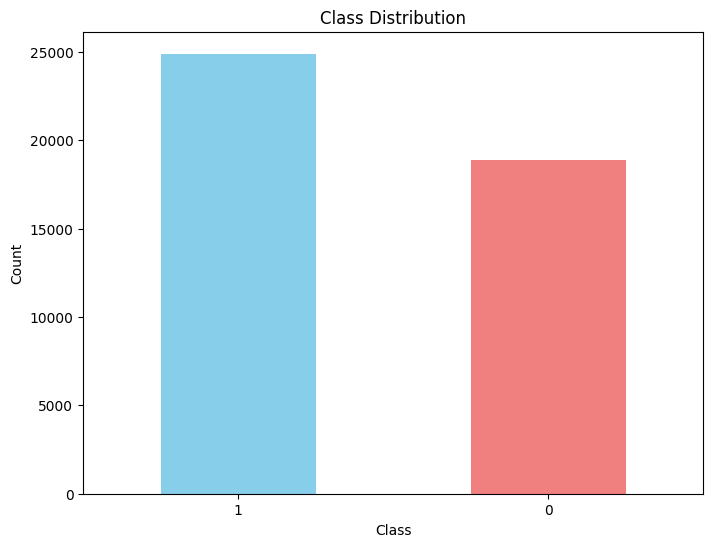

In [ ]:
import matplotlib.pyplot as plt

# Class distribution in the 'class' column
class_distribution = df['class'].value_counts()

# Plotting the class distribution
plt.figure(figsize=(8, 6))
class_distribution.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [7]:
from sklearn.model_selection import train_test_split

# Splitting the data into features (X) and target (y)
X = df.drop(columns=['class'])  # Features
y = df['class']  # Target variable

# Splitting the data into a training set (80%) and a testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Displaying the shapes of the resulting sets
print("Training set shape: ", X_train.shape, y_train.shape)
print("Testing set shape: ", X_test.shape, y_test.shape)


Training set shape:  (35893, 8) (35893,)
Testing set shape:  (8974, 8) (8974,)


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=10)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf_model = rf_model.predict(X_test)

# Evaluate the model
classification_rep_rf_model = classification_report(y_test, y_pred_rf_model)
confusion_mat_rf_model = confusion_matrix(y_test, y_pred_rf_model)

# Print the classification report
print("Classification Report:")
print(classification_rep_rf_model)

# Calculate the ROC AUC score
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC Score: {roc_auc}")



Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3838
           1       0.99      0.94      0.96      5136

    accuracy                           0.96      8974
   macro avg       0.95      0.96      0.96      8974
weighted avg       0.96      0.96      0.96      8974

ROC AUC Score: 0.9943010256510157


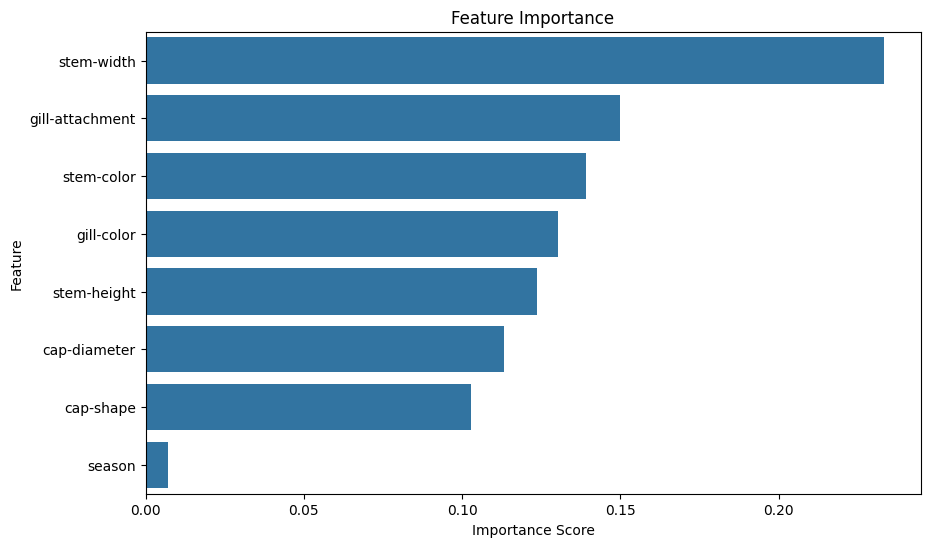

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = rf_model.feature_importances_

# Create a DataFrame to hold feature names and their importance scores
importance_df = pd.DataFrame({
    'Feature': X_train.columns,    # Feature names
    'Importance': feature_importances
})

# Sort the features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualize the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Calculate the training accuracy
train_accuracy = rf_model.score(X_train, y_train)

# Calculate the testing accuracy
test_accuracy = rf_model.score(X_test, y_test)

# Predict on the training set and testing set
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Get the classification report for the training set
classification_rep_train = classification_report(y_train, y_pred_train)

# Get the classification report for the test set
classification_rep_test = classification_report(y_test, y_pred_test)

# Output the results
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("\nClassification Report for Training Set:")
print(classification_rep_train)
print("\nClassification Report for Testing Set:")
print(classification_rep_test)



Training Accuracy: 0.9637407251854962
Testing Accuracy: 0.9563220965393661

Classification Report for Training Set:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     15343
           1       0.99      0.95      0.97     20372

    accuracy                           0.96     35715
   macro avg       0.96      0.97      0.96     35715
weighted avg       0.97      0.96      0.96     35715


Classification Report for Testing Set:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3836
           1       0.98      0.94      0.96      5093

    accuracy                           0.96      8929
   macro avg       0.95      0.96      0.96      8929
weighted avg       0.96      0.96      0.96      8929



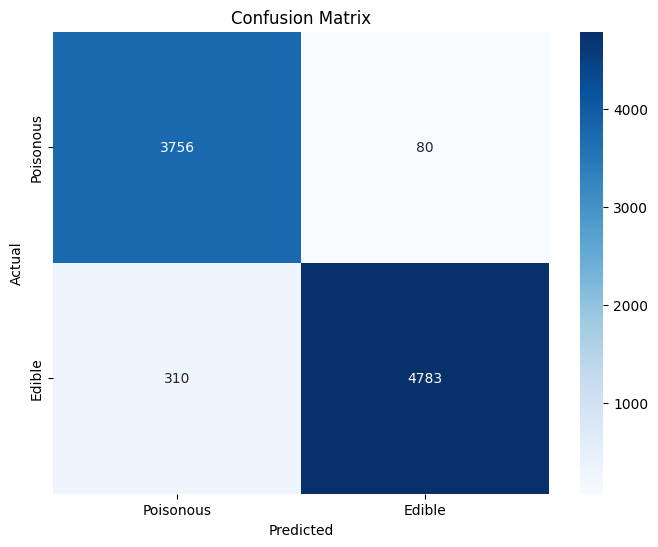

In [ ]:

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat_rf_model, annot=True, fmt='d', cmap="Blues", xticklabels=["Poisonous", "Edible"], yticklabels=["Poisonous", "Edible"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2: Training the Logistic Regression model with standardized data
log_reg_model_scaled = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
log_reg_model_scaled.fit(X_train_scaled, y_train)

# Step 3: Evaluating the Logistic Regression model (standardized data)
y_pred_log_reg_model_scaled = log_reg_model_scaled.predict(X_test_scaled)

# Classification report
classification_rep_log_reg_model_scaled = classification_report(y_test, y_pred_log_reg_model_scaled)

# Confusion Matrix
confusion_mat_log_reg_model_scaled = confusion_matrix(y_test, y_pred_log_reg_model_scaled)

# ROC AUC Score
y_pred_prob_log_reg_scaled = log_reg_model_scaled.predict_proba(X_test_scaled)[:, 1]
roc_auc_log_reg_scaled = roc_auc_score(y_test, y_pred_prob_log_reg_scaled)

# Output the results
print("Logistic Regression Classification Report (Standardized):")
print(classification_rep_log_reg_model_scaled)

print(f"\nLogistic Regression ROC AUC Score (Standardized): {roc_auc_log_reg_scaled}")




Logistic Regression Classification Report (Standardized):
              precision    recall  f1-score   support

           0       0.57      0.67      0.62      3838
           1       0.72      0.62      0.66      5136

    accuracy                           0.64      8974
   macro avg       0.64      0.65      0.64      8974
weighted avg       0.65      0.64      0.64      8974


Logistic Regression ROC AUC Score (Standardized): 0.6923116453922815


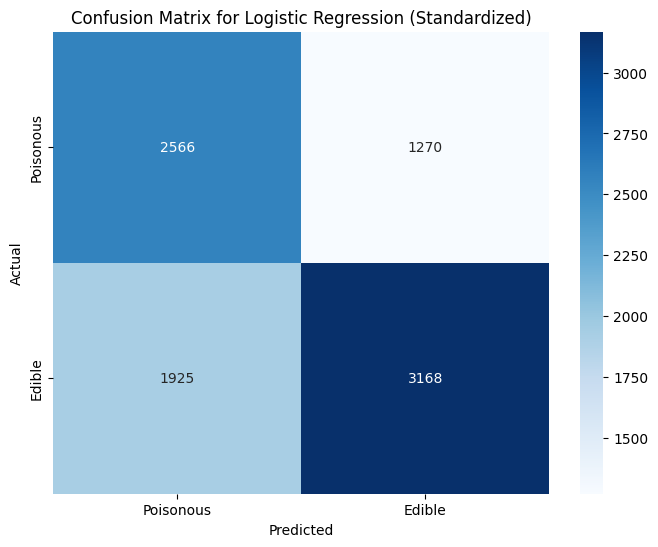

In [ ]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat_log_reg_model_scaled, annot=True, fmt='d', cmap="Blues", xticklabels=["Poisonous", "Edible"], yticklabels=["Poisonous", "Edible"])
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict on the test set
y_pred_nb_model = nb_model.predict(X_test)

# Evaluate the model
classification_rep_nb_model = classification_report(y_test, y_pred_nb_model)
confusion_mat_nb_model = confusion_matrix(y_test, y_pred_nb_model)

# Print the classification report
print("Naive Bayes Classification Report:")
print(classification_rep_nb_model)

# Calculate the ROC AUC score
y_pred_prob_nb = nb_model.predict_proba(X_test)[:, 1]  # Probability for the positive class (Edible)
roc_auc_nb = roc_auc_score(y_test, y_pred_prob_nb)
print(f"Naive Bayes ROC AUC Score: {roc_auc_nb}")


Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.59      0.59      3838
           1       0.69      0.68      0.69      5136

    accuracy                           0.64      8974
   macro avg       0.64      0.64      0.64      8974
weighted avg       0.64      0.64      0.64      8974

Naive Bayes ROC AUC Score: 0.6918146376861001


In [14]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score
import numpy as np

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=10)

# Perform cross-validation and get accuracy scores for each fold
cv_accuracy = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

# Print the accuracy for each fold
print(f"Cross-validation accuracy scores for each fold: {cv_accuracy}")

# Print the average cross-validation accuracy and standard deviation
print(f"Average cross-validation accuracy: {np.mean(cv_accuracy)}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_accuracy)}")






Cross-validation accuracy scores for each fold: [0.95946511 0.96002229 0.9568185  0.95959877 0.96322095]
Average cross-validation accuracy: 0.9598251238257959
Standard deviation of cross-validation accuracy: 0.002039174916965911


In [16]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Perform Randomized Search with 3-fold cross-validation
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist, n_iter=10, cv=3, n_jobs=-1, scoring='accuracy', random_state=42)

# Perform the randomized search
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters from Randomized Search:", random_search.best_params_)
print("Best Cross-validation Accuracy from Randomized Search:", random_search.best_score_)

# Get the best accuracy from RandomizedSearchCV
best_accuracy_random = random_search.best_score_
print(f"Best Accuracy from Randomized Search: {best_accuracy_random}")


Best Parameters from Randomized Search: {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
Best Cross-validation Accuracy from Randomized Search: 0.9871283861334664
Best Accuracy from Randomized Search: 0.9871283861334664


Best Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3838
           1       0.99      0.99      0.99      5136

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



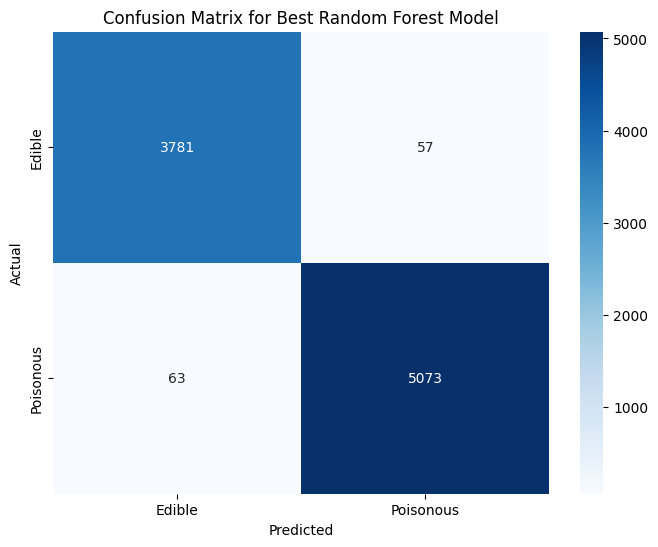

Best Random Forest ROC AUC Score: 0.998827641156885


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Best hyperparameters from Randomized Search
best_rf_model = random_search.best_estimator_

# Train the model with the best parameters on the training set
best_rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_best_rf = best_rf_model.predict(X_test)

# Generate the classification report
classification_rep_best_rf = classification_report(y_test, y_pred_best_rf)
print("Best Random Forest Classification Report:")
print(classification_rep_best_rf)

# Confusion Matrix
conf_matrix_best_rf = confusion_matrix(y_test, y_pred_best_rf)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_rf, annot=True, fmt='d', cmap="Blues", xticklabels=["Edible", "Poisonous"], yticklabels=["Edible", "Poisonous"])
plt.title("Confusion Matrix for Best Random Forest Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Calculate the ROC AUC score for the best model
y_pred_prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]  # Probability for the positive class (Edible)
roc_auc_best_rf = roc_auc_score(y_test, y_pred_prob_best_rf)
print(f"Best Random Forest ROC AUC Score: {roc_auc_best_rf}")


In [19]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

# Step 1: Load the new dataset
df_new = pd.read_csv('new_Dataset.csv')
X_new = df_new.drop(columns=['class'])
y_new = df_new['class']

y_pred_best_rf = best_rf_model.predict(X_new)

# Step 5: Generate the classification report
classification_rep_best_rf = classification_report(y_new, y_pred_best_rf)
print("Best Random Forest Classification Report:")
print(classification_rep_best_rf)

# Step 6: Calculate the ROC AUC score for the best model
y_pred_prob_best_rf = best_rf_model.predict_proba(X_new)[:, 1]
roc_auc_best_rf = roc_auc_score(y_new, y_pred_prob_best_rf)
print(f"Best Random Forest ROC AUC Score: {roc_auc_best_rf}")


Best Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        51
           1       0.96      0.98      0.97        49

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

Best Random Forest ROC AUC Score: 0.9983993597438975
